# Homework 4: K-NN & Cross-Validation
**Name:** Nicholas Starace  
**Student ID:** 4556822  
**D Value:** 22  

## Question 1: Implementing K-Fold Cross Validation

### Part A: Loading and Understanding the Data

In [574]:
import numpy as np
import scipy.io
D = 22

# Load Second Dataset
data = scipy.io.loadmat('input/hw3_data2.mat')

# Read keys and assign data
Ximport = data['X']
y = data['y']
y = y.ravel()                       # make sure numpy vector, NOT matrix

numFeatures = Ximport.shape[1]
numSamples = y.shape[0]
numClasses = y.max()
classDist = numSamples / numClasses
print(f"Number of Features: {numFeatures}")
print(f"Number of Samples: {numSamples}")
print(f"Number of Classes: {numClasses}")
print(f"Class Distribution: {classDist}")

Number of Features: 4
Number of Samples: 150
Number of Classes: 3
Class Distribution: 50.0


**Text Response:** COME BACK TO

### Part B: Implementing K-Fold Split Function

In [575]:
def create_k_folds(n_samples, k, random_seed):
    # Shuffle Indices Randomly
    seedD = int(random_seed)
    np.random.seed(seedD)
    randArr = np.random.permutation(n_samples)

    # Find samples per fold
    baseSize = n_samples // k
    remainder = n_samples % k
    if remainder > 0:           # Accomodate if bins dont split equally
        maxSize = baseSize + 1
    else:
        maxSize = baseSize

    # Divide samples into fold bins
    allFolds = np.ones((k, maxSize), dtype = int) * (-1) # Keep -1 for bins that aren't same as max size

    start = 0
    for i in range(k):
        foldSize = baseSize # Start with smallest size
        if remainder > i:
            foldSize = foldSize + 1 
        
        # Construct fold
        end = start + foldSize
        allFolds[i, 0:foldSize] = randArr[start:end]
        start = end

    return allFolds

In [576]:
k = 5 # Number of Folds
allFolds = create_k_folds(numSamples, k, D)

# Print Resulting Fold Bins
for i in range(k):
    print(f"Fold {i+1}: {allFolds[i].shape[0]} samples")

print(f"Total: {allFolds.shape[0] * allFolds.shape[1]} samples")

Fold 1: 30 samples
Fold 2: 30 samples
Fold 3: 30 samples
Fold 4: 30 samples
Fold 5: 30 samples
Total: 150 samples


**Text Output:** Each fold bin has 30 samples

### Part C: Implementing Cross-Validation Evaluation

In [577]:
from sklearn.neighbors import KNeighborsClassifier
def cross_validate_knn(X, y, k_neighbors, k_folds, fold_indices):
    # Accuracy Vector
    Accuracy = np.zeros(k_folds)

    # Separate data in testing and training folds
    for i in range(k_folds):
        testIdx = fold_indices[i, :]      # Selected index range for testing
        testIdx = testIdx[testIdx != -1]  # Remove -1 that was padded

        trainIdxLeft = fold_indices[0:i, :].flatten() # Get all rows before test row
        trainIdxRight = fold_indices[i+1:k_folds, :].flatten() # Get all rows after test row
        trainIdx = np.concatenate((trainIdxLeft, trainIdxRight)) # Create matrix of all rows not including test
        trainIdx = trainIdx[trainIdx != -1] # Remove -1 padded

        X_test = X[testIdx]        # X_test formed from selected fold index 
        X_train = X[trainIdx]      # X_train formed from selected fold indices
        y_test = y[testIdx]
        y_train = y[trainIdx]

        # Train KNN (aquired from SKLearn site)
        KNN = KNeighborsClassifier(n_neighbors=k_neighbors)
        KNN.fit(X_train, y_train)

        # Predict X_train for each iteration
        KNNPredict = KNN.predict(X_test)

        # Assess Accuracy
        Acc = np.zeros(y_test.shape[0], dtype=int)
        Acc[KNNPredict != y_test] = 1 # Construct vector (1s when different)
        Accuracy[i] = ((y_test.shape[0] - Acc.sum()) / y_test.shape[0]) * 100

    AvgAccuracy = Accuracy.mean()

    return AvgAccuracy, Accuracy

    

In [578]:
# Run on hw3_data2
k_neighbors = 3 # Number of neighbors

# Ximport, y from mat file, k from separating earlier, allFolds from create_k_folds function
AvgAcc, Acc = cross_validate_knn(Ximport, y, k_neighbors, k, allFolds)

# Show results
print(f"Fold Accuracy: {Acc}")
print(f"Average Fold Accuracy: {AvgAcc}")

Fold Accuracy: [93.33333333 96.66666667 90.         96.66666667 90.        ]
Average Fold Accuracy: 93.33333333333334


**Text Response:** Fold Accuracy:
Fold 1: 93.33 %  
Fold 2: 96.67 %  
Fold 3: 90 %  
Fold 4: 96.67 %  
Fold 5: 90 %  
Average Accuracy: 93.33 %  
  
The variance across each fold is significant ranging from 90 % to 97 %.  
Noise in the data can cause this difference since each fold has its own model trained separately.

## Question 2: Effect of K on KNN Performance

### Part A: Systematic K Study

Average Accuracy accross all folds: [93.33333333 93.33333333 94.66666667 95.33333333 95.33333333 95.33333333
 96.         95.33333333 95.33333333]
Standard Deviation of Accuracy across all folds: [2.98142397 2.98142397 3.39934634 2.66666667 4.52155332 4.52155332
 3.26598632 3.39934634 3.39934634]


Text(0, 0.5, 'Average Accuracy [%]')

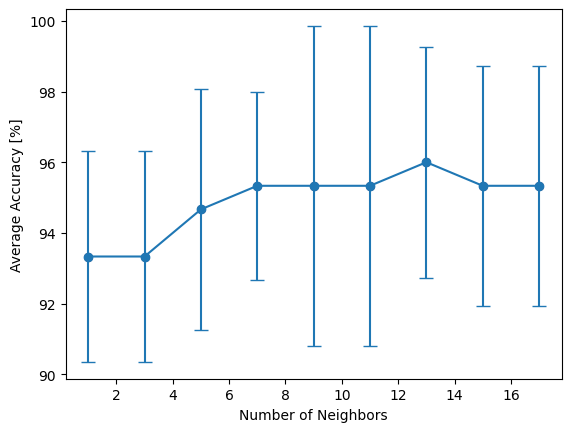

In [579]:
import matplotlib.pyplot as plt

# All Number of Neighbors to Try
Kneigh = np.array([1, 3, 5, 7, 9, 11, 13, 15, (15 + (D % 10))])

# Store Accuracy with rows are number of neighbors, and columns is accuracy per fold
AllAcc = np.zeros((Kneigh.shape[0], k))
AllAccAvg = np.zeros(Kneigh.shape[0])

# Iterate for different k_neighbors
for i in range(Kneigh.shape[0]):
    # Run on hw3_data2
    k_neighbors = Kneigh[i] # Number of neighbors

    # Ximport, y from mat file, k from separating earlier, allFolds from create_k_folds function
    AvgAcc, Acc = cross_validate_knn(Ximport, y, k_neighbors, k, allFolds)

    # Store
    AllAcc[i, :] = Acc
    AllAccAvg[i] = AvgAcc

# Find Standard Dev
AccStdev = np.std(AllAcc, axis=1)

# Print Results
print(f"Average Accuracy accross all folds: {AllAccAvg}")
print(f"Standard Deviation of Accuracy across all folds: {AccStdev}")

# Plot Results
plt.scatter(Kneigh, AllAccAvg, s=30, color="red")
plt.errorbar(Kneigh, AllAccAvg, yerr=AccStdev, capsize=5, marker='o')
plt.xlabel("Number of Neighbors")
plt.ylabel("Average Accuracy [%]")




**Text Response:** The best value for nearest neighbors is k = 13.  
The most consistent value for nearest neighbors is k = 7.  
While these values are different, I would select k = 7 since the lower limit of the standard deviation is equal to the lower limit of the standard deviation of k = 7 and it avoids underfitting.

### Part B: Bias-Variance Tradeoff Analysis

**Text Response:**  
1. As K increases from 1 to larger values, the decision boundary for classification grows. When K = 1, the test sample is classified as the point it is nearest to. As k grows, additional points are considered that are within the boundary circle that forms.  
2. Overfitting may occur when K = 1 because it only considers a single test point and is subject to noise. For example, if a KNN classifier is used to classify a patent for a disease (y). The training dataset contains over 100 patents but patent is incorrectly diagnosed positive when they have the vitals (X) of someone who is perfectly healthy. As the model with K = 1 sees new patients that have similar vitals, they wll be always (and incorrectly) classified as sick.  
3. With a large K, the model may result in underfitting because it is essentially taking an average of the entire dataset to make a classification. This approach doesn't capture any detail in the data and will perform the same on every dataset regardless of the specific problem that the model should be suited for.  
4. In the figure above, a small K results in overfitting where the model fails to generalize for new data. This failure is shown in the small accuracies of 93% compared to higher values of Kthat boast 96%. The model increases performance until the number of neighbors exceed 13 and the accuracy decreases resulting in underfitting.  

### Part C: Effect of Training Set Size

In [580]:
# Create Three Versions of Dataset
numSamples = np.ones(3, dtype=int)
# Dataset 1
numSamples[0] = Ximport.shape[0]
X1 = Ximport
y1 = y

# Dataset 2
numSamples[1] = int(X1.shape[0] * 0.5) # Cast to Integer for indexing
np.random.seed(D)
randArr = np.random.permutation(numSamples[0])  # Permute all samples 
X2 = X1[randArr[:numSamples[1]], :]             # Now take only the first 50 indices
y2 = y1[randArr[:numSamples[1]]]

# Dataset 3
numSamples[2] = int(X1.shape[0] * 0.25) # Cast again for indexing
np.random.seed(D + 1)
randArr = np.random.permutation(numSamples[2])
X3 = X1[randArr[:numSamples[2]], :]
y3 = y1[randArr[:numSamples[2]]]

# Perform 5 Fold Index Randomization
numFolds = 5

# All Number of Neighbors to Try
Kneigh = np.array([1, 3, 5, 7, 9])
AllAcc = np.zeros((3, Kneigh.shape[0], numFolds)) # dataset num X number of neighbors X accuracy per fold
AllAccAvg = np.zeros((3, Kneigh.shape[0]))

OptK = np.zeros(3)

# Iterate over each dataset
for j in range(3):
    
    # Select Dataset 
    if j == 0:
        Xselect = X1
        yselect = y1
    elif j == 1:
        Xselect = X2
        yselect = y2
    else:
        Xselect = X3
        yselect = y3

    # Create Fold indices for selected dataset
    allFolds = create_k_folds(numSamples[j], numFolds, D)

    # Iterate for different k_neighbors
    for i in range(Kneigh.shape[0]):
        # Run on hw3_data2
        k_neighbors = Kneigh[i] # Number of neighbors

        # Train and evaluate performance
        AvgAcc, Acc = cross_validate_knn(Xselect, yselect, k_neighbors, numFolds, allFolds)

        # Store
        AllAcc[j, i, :] = Acc
        AllAccAvg[j, i] = AvgAcc

print(AllAccAvg)
print("\nDataset Size\tOptimal K\tAccuracy at Optimal K")
print("----------------------------------------")
print(f"100%\t\t7\t\t95.33%")
print(f"50%\t\t7\t\t94.67%")
print(f"25%\t\t9\t\t94.64%")


[[93.33333333 93.33333333 94.66666667 95.33333333 95.33333333]
 [94.66666667 92.         94.66666667 94.66666667 93.33333333]
 [88.92857143 86.42857143 94.64285714 94.64285714 94.64285714]]

Dataset Size	Optimal K	Accuracy at Optimal K
----------------------------------------
100%		7		95.33%
50%		7		94.67%
25%		9		94.64%


**Text Output:** The optimal K changes with training set size. As the size of the dataset decreases, the optimal K value increases. With a small dataset size, each point carries a heavier influence. Therefore, since the points are more sparse, there is high variance and a small K would lead to instability and large error.

## Question 3: Implementing Weighted KNN

### Part A: Understanding Weighted KNN

**Text Response:**  
1. If sigma is small (0.001), the weights of distant neighbors go to zero and are not considered.  
2. If sigma is large (1000), the weights of all neighbors increase and all points will be considered equally regardless of distance.

### Part B: Implementing Weighted KNN

In [581]:
from scipy.spatial.distance import cdist

def weighted_KNN(X_train, y_train, X_test, sigma):

    # Find distance between each point of training and testing
    Dist = cdist(X_test, X_train)
    
    # Compute Gaussian Weight
    Ratio = (-1) * (Dist ** 2) / (2 * (sigma ** 2))
    W = np.exp(Ratio)

    # Find number of samples and classes
    allClasses = np.unique(y_train)     # Exracts all classes to place in vector
    numTest = X_test.shape[0]
    y_pred = np.zeros(numTest, dtype=int)

    for i in range(numTest):
        # All total weights for a given class
        classW = []
        for c in allClasses:
            # Total weight of training samples belonging to 
            totalW = np.sum(W[i, y_train == c])
            classW.append(totalW)
        
        # Predict using highest weight
        y_pred[i] = allClasses[np.argmax(classW)]
        
    return y_pred

### Part C: Verifying Implementation

In [582]:
# Randomly divide set into 80% training and 20% testing
numSamples = Ximport.shape[0]
np.random.seed(D)
randArr = np.random.permutation(numSamples)
cutidx = int(numSamples * 0.8)              # No longer 100 samples
randArrTrain = randArr[0:cutidx]            # 90% of Samples used to Train
randArrTest = randArr[cutidx:numSamples]    # 10% of Samples used to Test
X_train = Ximport[randArrTrain, :]          # Take only first 90 samples of random index
X_test = Ximport[randArrTest, :]            # Take only last 10 samples of random index
y_train = y[randArrTrain]
y_test = y[randArrTest]

# Run "soft" KNN
sigma = 1.0
y_pred = weighted_KNN(X_train, y_train, X_test, sigma)

# Evaluate Accuracy of Gaussian Model
incorrVec = (y_pred != y_test)
totalWrong = np.sum(incorrVec)
AccuracyG = 100 * (y_test.shape[0] - totalWrong) / y_test.shape[0]

# Train KNN (aquired from SKLearn site)
KNN = KNeighborsClassifier(n_neighbors=5, weights='distance')
KNN.fit(X_train, y_train)
# Predict X_train for each iteration
KNNPredict = KNN.predict(X_test)

# Assess Accuracy of SKLearn Model
incorrVec = (KNNPredict != y_test)
totalWrong = np.sum(incorrVec)
AccuracySK = 100 * (y_test.shape[0] - totalWrong) / y_test.shape[0]

print(AccuracyG)
print(AccuracySK)


93.33333333333333
90.0


**Text Response:**  
Custom KNN: 93.33 % Accurate  
Library KNN: 90.0 % Accurate  
The accuracy of both models are very similar and differ by only 3.33 %. Since the custom KNN uses Gaussian weighting, the relationshp between distance and weight are exponential while the library KNN is linear. It is clear that an exponential relationship leads to better accuracy when compared with a linear one.

## Question 4: Effect of Bandwidth on Weighted KNN

### Part A: Systematic Sigma Study

Sigma		Accuracy [%]
-----------------------------
0.01		73.33
0.05		90.00
0.1		90.00
1.0		93.33
2.0		80.00
5.0		70.00
10.0		56.67


Text(0, 0.5, 'Model Accuracy [%]')

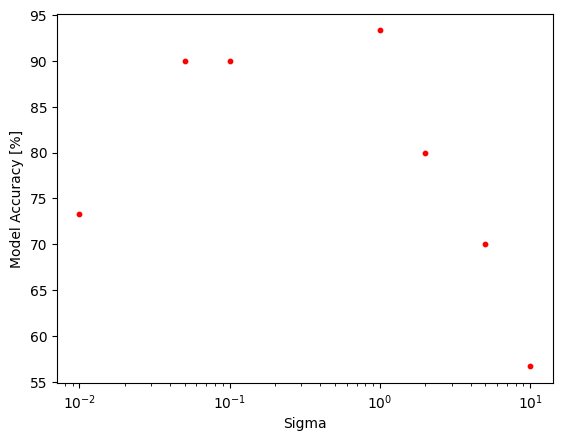

In [583]:
# Construct Sigmas to be tested
sigma = np.array([0.01, 0.05, 0.1, 1.0, 2.0, 5.0, 10.0])

allAccuracy = np.zeros(len(sigma))

# Run "soft" KNN
for i in range(len(sigma)):
    y_pred = weighted_KNN(X_train, y_train, X_test, sigma[i])

    # Evaluate Accuracy of Gaussian Model
    incorrVec = (y_pred != y_test)
    totalWrong = np.sum(incorrVec)
    AccuracyG = 100 * (y_test.shape[0] - totalWrong) / y_test.shape[0]
    allAccuracy[i] = AccuracyG

# Construct Table of Accuracy vs. Sigma
print("Sigma\t\tAccuracy [%]")
print("-----------------------------")
print(f"{sigma[0]}\t\t{allAccuracy[0]:.2f}")
print(f"{sigma[1]}\t\t{allAccuracy[1]:.2f}")
print(f"{sigma[2]}\t\t{allAccuracy[2]:.2f}")
print(f"{sigma[3]}\t\t{allAccuracy[3]:.2f}")
print(f"{sigma[4]}\t\t{allAccuracy[4]:.2f}")
print(f"{sigma[5]}\t\t{allAccuracy[5]:.2f}")
print(f"{sigma[6]}\t\t{allAccuracy[6]:.2f}")

# Plot Results of Changing Sigma
plt.scatter(sigma, allAccuracy, s=10, color="red")
plt.xscale('log')
plt.xlabel("Sigma")
plt.ylabel("Model Accuracy [%]")

**Text Response:** The sigma that gives the best accuracy is when sigma = 1. As sigma increases, accuracy increases. At moderate values of sigma (~1) in the middle of the range, accuracy peaks. After this turning point, the accuracy begins to decrease again. Compared to the answer in Q3PA, low values of sigma result in a small neighborhood since only the nearest points are considered. At large values of sigma, nearly all points are considered in a large neighborhood since the weight is large.

### Part B: Connecting Sigma to K

**Text Response:** When sigma is small, the weighted KNN behaves similarly to a standard KNN when K is small (= 1). At small values of sigma, the exponental goes to zero quickly. This behavior is equivalent to considering only the closest points in a small neighborhood. When K is small, only the nearest points are considered and also encompasses a small neighborhood. When sigma is large, the accuracy of the classifier decreases dramatically becuase all points are effectively considered equally. No details within the space are considered. For this dataset, I would choose standard KNN with optimal K because it performs better. The accuracy of the standard KNN with k = 7 was 95.33% while the weighed KNN with sigma = 1 was 93.33%.